# Task 2 — Unemployment Analysis with Python

Objective: analyze regional and temporal unemployment trends in India with focus on COVID-19.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
df=pd.read_csv("unemployment.csv"); df.columns=df.columns.str.strip(); print("Shape:",df.shape); display(df.head()); print(df.dtypes); print(df.isnull().sum()); display(df.describe(include="all"))

Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                       str
longitude                                  float64
latitude                                   float64
dtype: object
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
count,267,267,267,267.000000,2.670000e+02,267.000000,267,267.000000,267.000000
unique,27,10,1,NaN,NaN,NaN,5,NaN,NaN
top,Andhra Pradesh,31-03-2020,M,NaN,NaN,NaN,North,NaN,NaN
freq,10,27,267,NaN,NaN,NaN,79,NaN,NaN
mean,NaN,NaN,NaN,12.236929,1.396211e+07,41.681573,NaN,22.826048,80.532425
std,NaN,NaN,NaN,10.803283,1.336632e+07,7.845419,NaN,6.270731,5.831738
min,NaN,NaN,NaN,0.500000,1.175420e+05,16.770000,NaN,10.850500,71.192400
25%,NaN,NaN,NaN,4.845000,2.838930e+06,37.265000,NaN,18.112400,76.085600
50%,NaN,NaN,NaN,9.650000,9.732417e+06,40.390000,NaN,23.610200,79.019300
75%,NaN,NaN,NaN,16.755000,2.187869e+07,44.055000,NaN,27.278400,85.279900


In [2]:
rename={"Region":"State","Estimated Unemployment Rate (%)":"Unemployment Rate (%)","Estimated Labour Participation Rate (%)":"Labour Participation Rate (%)","Region.1":"Region"}; df=df.rename(columns=rename); df["Date"]=pd.to_datetime(df["Date"],dayfirst=True,errors="coerce")
for c in ["Unemployment Rate (%)","Estimated Employed","Labour Participation Rate (%)"]: df[c]=pd.to_numeric(df[c],errors="coerce")
df=df.dropna(subset=["State","Date","Unemployment Rate (%)","Estimated Employed","Labour Participation Rate (%)"]).copy(); df["Month"]=df.Date.dt.month_name(); df["Year"]=df.Date.dt.year

## 1. Region-wise average unemployment rate

,Average Unemployment Rate (%)
State,
Haryana,27.477000
Tripura,25.055000
Jharkhand,19.539000
Bihar,19.471000
Delhi,18.414000
Puducherry,17.942000
Jammu & Kashmir,16.477778
Himachal Pradesh,16.065000
Rajasthan,15.868000


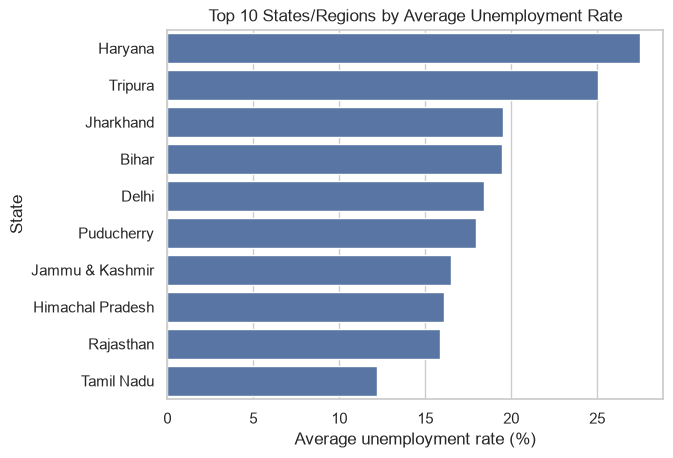

In [3]:
avg=df.groupby("State")["Unemployment Rate (%)"].mean().sort_values(ascending=False); display(avg.to_frame("Average Unemployment Rate (%)").head(10)); sns.barplot(x=avg.head(10).values,y=avg.head(10).index); plt.title("Top 10 States/Regions by Average Unemployment Rate"); plt.xlabel("Average unemployment rate (%)"); plt.show()

**Observation:** This chart ranks the highest average reported unemployment rates over the dataset period; it is not a current ranking.

## 2. Month-wise trends

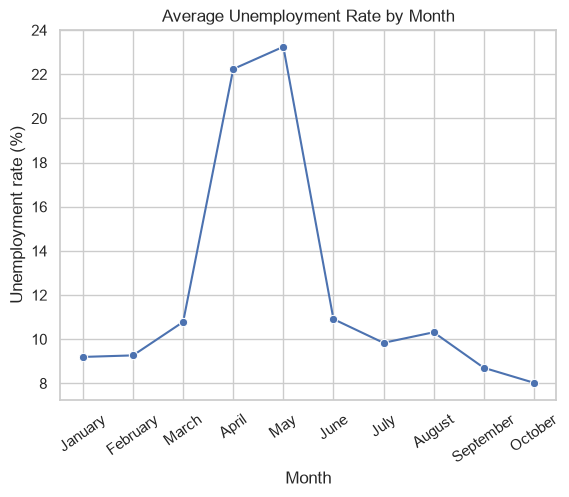

In [4]:
order=["January","February","March","April","May","June","July","August","September","October","November","December"]; m=df.groupby("Month")["Unemployment Rate (%)"].mean().reindex(order); sns.lineplot(x=m.index,y=m.values,marker="o"); plt.xticks(rotation=35); plt.title("Average Unemployment Rate by Month"); plt.ylabel("Unemployment rate (%)"); plt.show()

**Observation:** Monthly aggregation reveals calendar patterns; the time-series view should be used to distinguish seasonality from the 2020 shock.

## 3. Time series for three major states/regions

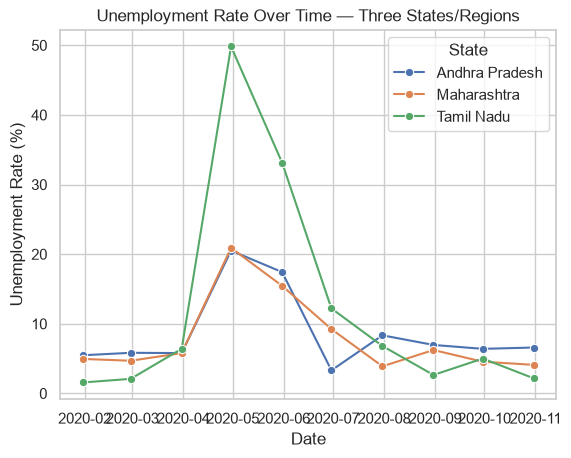

States: ['Andhra Pradesh', 'Tamil Nadu', 'Maharashtra']


In [5]:
pref=["Andhra Pradesh","Tamil Nadu","Maharashtra","Karnataka","Delhi"]; chosen=[s for s in pref if s in df.State.unique()][:3]
if len(chosen)<3: chosen=df.State.value_counts().head(3).index.tolist()
t=df[df.State.isin(chosen)].groupby(["Date","State"])["Unemployment Rate (%)"].mean().reset_index(); sns.lineplot(data=t,x="Date",y="Unemployment Rate (%)",hue="State",marker="o"); plt.title("Unemployment Rate Over Time — Three States/Regions"); plt.show(); print("States:",chosen)

**Observation:** State-level unemployment responses vary in size and timing; regional analysis prevents the national picture from hiding local differences.

## 4. Correlation heatmap

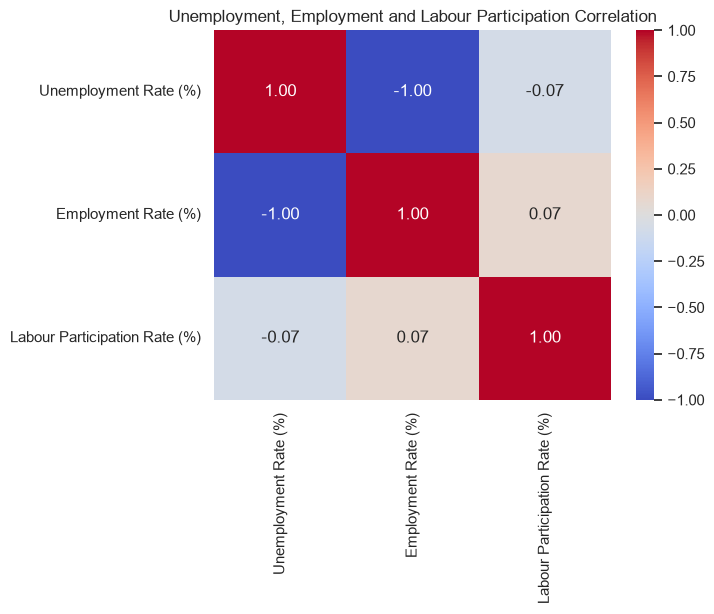

In [6]:
# The Kaggle dataset provides an estimated employed count, not a direct employment-rate percentage.
# To satisfy the requested three-rate comparison without inventing a population denominator,
# we use the employment share within the labour force: 100 - unemployment rate.
df["Employment Rate (%)"] = 100 - df["Unemployment Rate (%)"]
cols=["Unemployment Rate (%)","Employment Rate (%)","Labour Participation Rate (%)"]
corr=df[cols].corr(); sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0); plt.title("Unemployment, Employment and Labour Participation Correlation"); plt.show()


**Interpretation:** The source dataset does not contain a direct employment-to-population rate. The plotted Employment Rate is the complementary share of the labour force not classified as unemployed (`100 - unemployment rate`), so this limitation is stated explicitly rather than fabricating a statistic.


## 5. Pre-COVID vs post-COVID

,Unemployment Rate (%),Estimated Employed,Labour Participation Rate (%)
Period,,,
Post-COVID,12.963860,1.357498e+07,41.023209
Pre-COVID,9.231346,1.556273e+07,44.403654


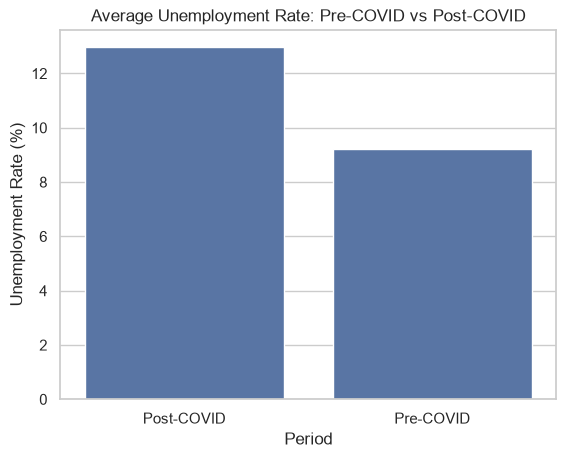

In [7]:
cut=pd.Timestamp("2020-03-01"); df["Period"]=np.where(df.Date<cut,"Pre-COVID","Post-COVID"); comp=df.groupby("Period")[["Unemployment Rate (%)","Estimated Employed","Labour Participation Rate (%)"]].mean(); display(comp); sns.barplot(data=comp.reset_index(),x="Period",y="Unemployment Rate (%)"); plt.title("Average Unemployment Rate: Pre-COVID vs Post-COVID"); plt.show()

**Observation:** The pre/post comparison quantifies the difference between the periods. It is descriptive, not a causal estimate of COVID-19.

## Final findings
State differences, strong temporal variation, a visible 2020 disruption, and changes in labour-market indicators are identified through the required charts and tables.